Time Domain Convolution: [3, 7, 14, 21, 13, 12]
Frequency Domain (IFFT result): [ 3.  7. 14. 21. 13. 12.]


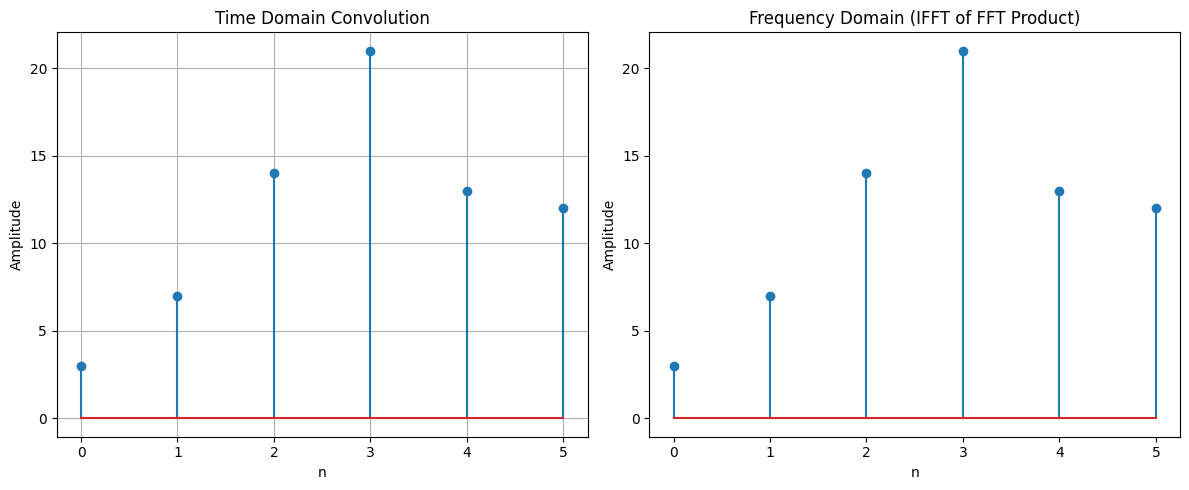

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# 🔥 1. Manual Convolution (Time Domain)
# ==================================================
def convolution(x, h):
    N = len(x)
    M = len(h)
    y = [0] * (N + M - 1)

    for n in range(N + M - 1):
        for k in range(N):
            if 0 <= n - k < M:
                y[n] += x[k] * h[n - k]
    return y



# ==================================================
# 🔥 Input Signals
# ==================================================
x1 = [1, 2, 3, 4]
x2 = [3, 1, 3]

# ==================================================
# 🔥 2. Time Domain Convolution
# ==================================================
time_conv = convolution(x1, x2)

print("Time Domain Convolution:", time_conv)


# ==================================================
# 🔥 3. Frequency Domain (FFT)
# ==================================================
N = len(x1) + len(x2) - 1

X1 = np.fft.fft(x1, N)
X2 = np.fft.fft(x2, N)

# Multiplication in frequency domain
X_product = X1 * X2


# ==================================================
# 🔥 4. IDFT (IFFT)
# ==================================================
freq_conv = np.fft.ifft(X_product).real

print("Frequency Domain (IFFT result):", np.round(freq_conv, 4))


# ==================================================
# 🔥 5. Verification Plot
# ==================================================
n = np.arange(N)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.stem(n, time_conv)
plt.title("Time Domain Convolution")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1,2,2)
plt.stem(n, freq_conv)
plt.title("Frequency Domain (IFFT of FFT Product)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()